# EDA for the financial sentiment datasets

This notebook assumes the processed outputs from `01_download_financial_sentiment_datasets.ipynb` already exist.

It focuses on:
- dataset sizes and split coverage
- normalized label balance
- text length distributions
- duplicate and overlap checks
- high-frequency vocabulary by dataset
- source-specific metadata slices where available

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    return start


ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = ROOT / "data" / "processed"
EXPORTS_DIR = ROOT / "data" / "exports"
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

combined_path = PROCESSED_DIR / "financial_sentiment_combined.csv"
manifest_path = PROCESSED_DIR / "download_manifest.json"

if not combined_path.exists():
    raise FileNotFoundError("Run notebooks/01_download_financial_sentiment_datasets.ipynb first.")

DATASET_DISPLAY_NAMES = {
    "lwrf42_financial_sentiment_dataset": "LWRF42 Financial Sentiment",
    "kenpache_multilingual_financial_sentiment_en": "Kenpache Financial Sentiment (EN)",
    "maguid28_combined_financial_phrasebank_twitter_news_sentiment": "Combined PhraseBank + Twitter News",
    "sbhatti_financial_sentiment_analysis": "Kaggle Financial Sentiment",
}
SENTIMENT_DISPLAY_NAMES = {
    "negative": "Negative",
    "neutral": "Neutral",
    "positive": "Positive",
    "missing": "Missing",
}

df = pd.read_csv(combined_path, low_memory=False)
manifest = pd.DataFrame(json.loads(manifest_path.read_text(encoding="utf-8"))) if manifest_path.exists() else pd.DataFrame()

df["text"] = df["text"].fillna("").astype(str).str.strip()
df["label_normalized"] = df["label_normalized"].fillna("missing").astype(str)
df["split"] = df["split"].fillna("unspecified").astype(str)
df["dataset_display"] = df["dataset_label"].map(DATASET_DISPLAY_NAMES).fillna(df["dataset_label"])
df["sentiment_display"] = df["label_normalized"].map(SENTIMENT_DISPLAY_NAMES).fillna(df["label_normalized"])
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["text_lower"] = df["text"].str.lower()
df["duplicate_within_dataset"] = df.duplicated(subset=["dataset_label", "text_lower"])
df["duplicate_global"] = df.duplicated(subset=["text_lower"])

display(manifest)
display(df.head())

,dataset_key,dataset_id,source_platform,status,split,rows,columns,unique_raw_labels,unique_normalized_labels,raw_snapshot,derived_from,csv_path,parquet_path
0,lwrf42_financial_sentiment_dataset,lwrf42/financial-sentiment-dataset,huggingface,downloaded,train,57132,11,9.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,"train,validation",NaN,NaN
1,lwrf42_financial_sentiment_dataset,lwrf42/financial-sentiment-dataset,huggingface,downloaded,validation,19044,11,9.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,"train,validation",NaN,NaN
2,lwrf42_financial_sentiment_dataset,lwrf42/financial-sentiment-dataset,huggingface,downloaded,test,19044,11,9.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,"train,validation",NaN,NaN
3,lwrf42_financial_sentiment_dataset,lwrf42/financial-sentiment-dataset,huggingface,exported,all,95220,6,NaN,NaN,NaN,NaN,/home/automac/Documents/Estudios/Semestre3/Pro...,/home/automac/Documents/Estudios/Semestre3/Pro...
4,kenpache_multilingual_financial_sentiment,Kenpache/multilingual-financial-sentiment,huggingface,downloaded,train,6887,11,3.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,train,NaN,NaN
5,kenpache_multilingual_financial_sentiment,Kenpache/multilingual-financial-sentiment,huggingface,downloaded,validation,0,11,0.0,0.0,/home/automac/Documents/Estudios/Semestre3/Pro...,train,NaN,NaN
6,kenpache_multilingual_financial_sentiment,Kenpache/multilingual-financial-sentiment,huggingface,downloaded,test,0,11,0.0,0.0,/home/automac/Documents/Estudios/Semestre3/Pro...,train,NaN,NaN
7,kenpache_multilingual_financial_sentiment,Kenpache/multilingual-financial-sentiment,huggingface,exported,all,6887,6,NaN,NaN,NaN,NaN,/home/automac/Documents/Estudios/Semestre3/Pro...,/home/automac/Documents/Estudios/Semestre3/Pro...
8,maguid28_combined_financial_phrasebank_twitter...,maguid28/combined_financial_phrasebank_twitter...,huggingface,downloaded,train,10067,8,3.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,train,NaN,NaN
9,maguid28_combined_financial_phrasebank_twitter...,maguid28/combined_financial_phrasebank_twitter...,huggingface,downloaded,validation,3355,8,3.0,3.0,/home/automac/Documents/Estudios/Semestre3/Pro...,train,NaN,NaN


,dataset_id,dataset_label,source_platform,split,text,label_normalized,dataset_display,sentiment_display,char_count,word_count,text_lower,duplicate_within_dataset,duplicate_global
0,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,general announcement monthly valuation of asse...,neutral,LWRF42 Financial Sentiment,Neutral,132,18,general announcement monthly valuation of asse...,False,False
1,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,cowen survey forecasts stores to reopen in jun...,positive,LWRF42 Financial Sentiment,Positive,113,19,cowen survey forecasts stores to reopen in jun...,False,False
2,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,aap weak no volume,negative,LWRF42 Financial Sentiment,Negative,18,4,aap weak no volume,False,False
3,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,rt robbielolz nflx a close above here is looki...,positive,LWRF42 Financial Sentiment,Positive,132,26,rt robbielolz nflx a close above here is looki...,False,False
4,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,apple s aapl third quarter fiscal earnings ben...,positive,LWRF42 Financial Sentiment,Positive,178,28,apple s aapl third quarter fiscal earnings ben...,False,False


In [2]:
dataset_summary = (
    df.groupby("dataset_label", dropna=False)
    .agg(
        rows=("text", "size"),
        splits=("split", lambda values: ", ".join(sorted(set(values)))),
        normalized_label_count=("label_normalized", lambda values: values.nunique(dropna=True)),
        avg_chars=("char_count", "mean"),
        median_words=("word_count", "median"),
        missing_text_pct=("text", lambda values: round((values.str.len() == 0).mean() * 100, 2)),
        duplicate_pct=("duplicate_within_dataset", lambda values: round(values.mean() * 100, 2)),
    )
    .reset_index()
)

label_distribution = pd.crosstab(df["dataset_label"], df["label_normalized"], normalize="index").round(3)
word_count_by_sentiment = (
    df.groupby(["dataset_label", "label_normalized"], dropna=False)
    .agg(
        rows=("text", "size"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        p90_words=("word_count", lambda values: values.quantile(0.9)),
        max_words=("word_count", "max"),
    )
    .reset_index()
)

display(dataset_summary.round({"avg_chars": 2, "median_words": 2}))
display(label_distribution)
display(word_count_by_sentiment.round({"mean_words": 2, "median_words": 2, "p90_words": 2}))

dataset_summary.to_csv(EXPORTS_DIR / "dataset_summary.csv", index=False)
label_distribution.to_csv(EXPORTS_DIR / "label_distribution_by_dataset.csv")
word_count_by_sentiment.to_csv(EXPORTS_DIR / "word_count_by_dataset_and_sentiment.csv", index=False)

,dataset_label,rows,splits,normalized_label_count,avg_chars,median_words,missing_text_pct,duplicate_pct
0,kenpache_multilingual_financial_sentiment_en,6887,train,3,153.90,24.0,0.0,0.89
1,lwrf42_financial_sentiment_dataset,95217,"test, train, validation",3,98.99,15.0,0.0,41.41
2,maguid28_combined_financial_phrasebank_twitter...,16776,"test, train, validation",3,90.61,14.0,0.0,0.53
3,sbhatti_financial_sentiment_analysis,5842,"test, train, validation",3,106.09,17.0,0.0,9.60


label_normalized,negative,neutral,positive
dataset_label,,,
kenpache_multilingual_financial_sentiment_en,0.247,0.485,0.268
lwrf42_financial_sentiment_dataset,0.267,0.240,0.493
maguid28_combined_financial_phrasebank_twitter_news_sentiment,0.143,0.633,0.224
sbhatti_financial_sentiment_analysis,0.147,0.536,0.317


,dataset_label,label_normalized,rows,mean_words,median_words,p90_words,max_words
0,kenpache_multilingual_financial_sentiment_en,negative,1704,26.13,24.0,41.0,80
1,kenpache_multilingual_financial_sentiment_en,neutral,3339,25.13,23.0,40.0,76
2,kenpache_multilingual_financial_sentiment_en,positive,1844,25.56,24.0,41.0,82
3,lwrf42_financial_sentiment_dataset,negative,25438,18.23,16.0,33.0,704
4,lwrf42_financial_sentiment_dataset,neutral,22879,16.64,15.0,27.0,156
5,lwrf42_financial_sentiment_dataset,positive,46900,17.56,15.0,31.0,645
6,maguid28_combined_financial_phrasebank_twitter...,negative,2393,15.26,14.0,25.0,49
7,maguid28_combined_financial_phrasebank_twitter...,neutral,10622,15.75,15.0,25.0,50
8,maguid28_combined_financial_phrasebank_twitter...,positive,3761,16.07,14.0,27.0,45
9,sbhatti_financial_sentiment_analysis,negative,860,16.84,15.0,28.0,49


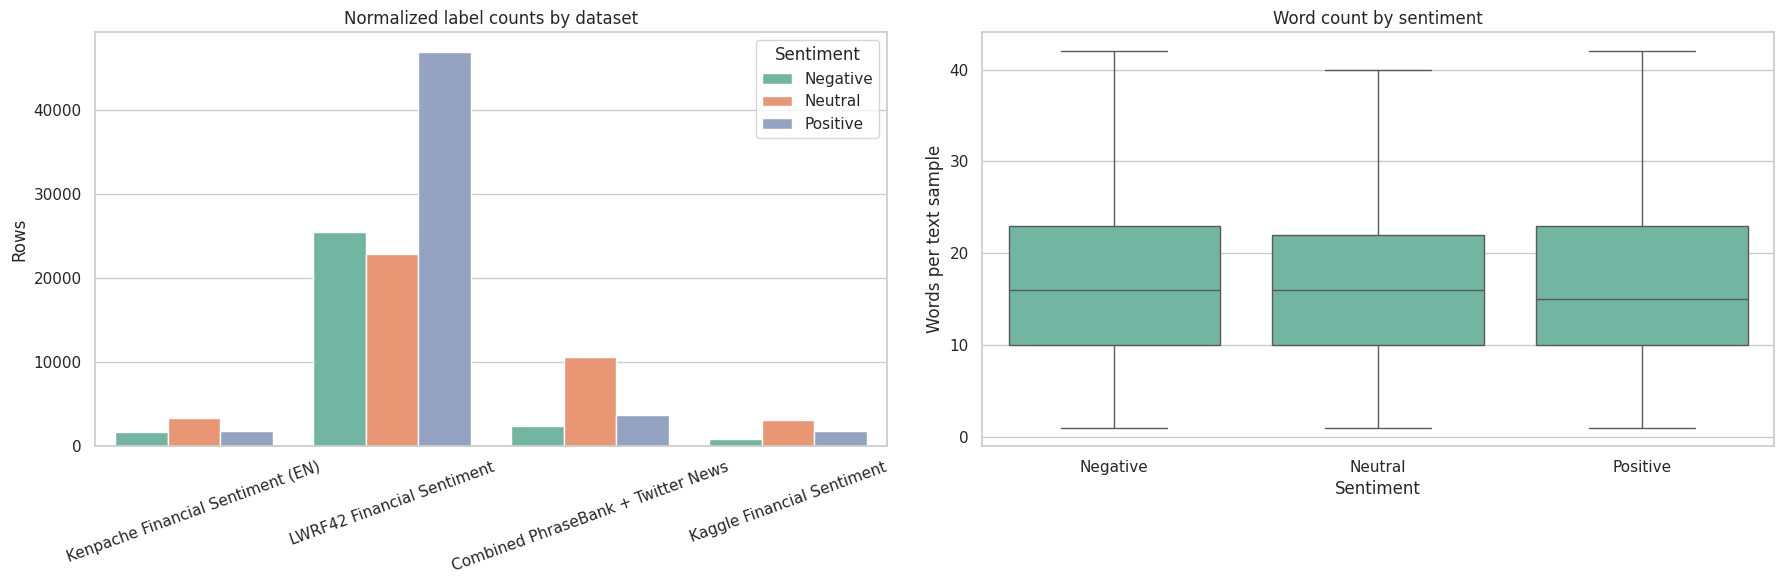

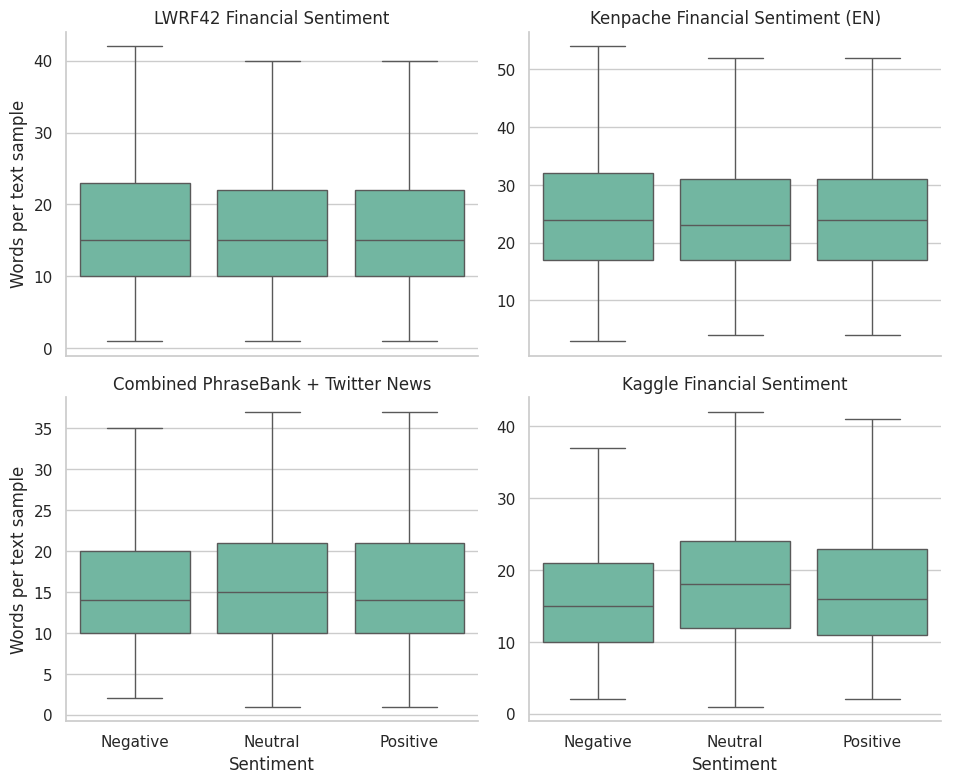

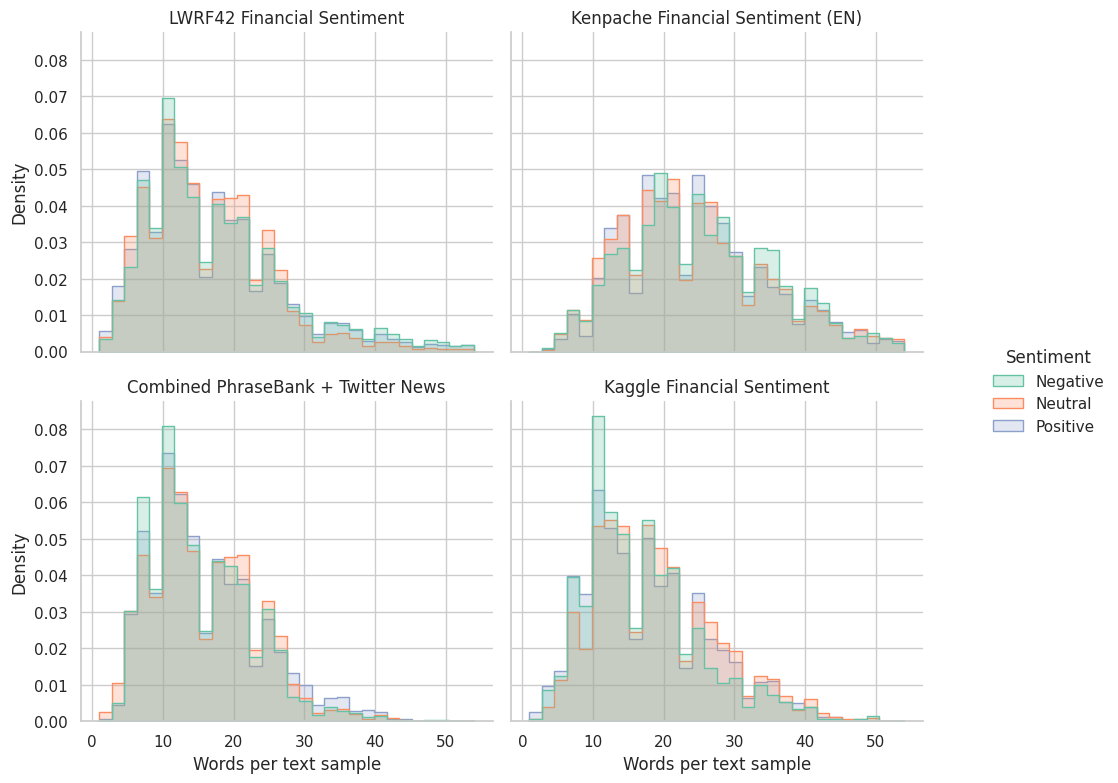

In [3]:
dataset_order = [
    DATASET_DISPLAY_NAMES.get(label, label)
    for label in sorted(df["dataset_label"].dropna().unique())
]
sentiment_order = [
    SENTIMENT_DISPLAY_NAMES.get(label, label)
    for label in ["negative", "neutral", "positive"]
    if label in set(df["label_normalized"])
]
word_limit = df["word_count"].quantile(0.99)
word_count_trimmed = df[df["word_count"] <= word_limit].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=df, x="dataset_display", hue="sentiment_display", order=dataset_order, hue_order=sentiment_order, ax=axes[0])
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_title("Normalized label counts by dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].legend(title="Sentiment")

sns.boxplot(data=df, x="sentiment_display", y="word_count", order=sentiment_order, showfliers=False, ax=axes[1])
axes[1].set_title("Word count by sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Words per text sample")

plt.tight_layout()
plt.show()

g = sns.catplot(
    data=word_count_trimmed,
    kind="box",
    x="sentiment_display",
    y="word_count",
    col="dataset_display",
    order=sentiment_order,
    col_wrap=2,
    sharey=False,
    showfliers=False,
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Sentiment", "Words per text sample")
g.set_titles("{col_name}")
plt.show()

g = sns.displot(
    data=word_count_trimmed,
    x="word_count",
    hue="sentiment_display",
    hue_order=sentiment_order,
    col="dataset_display",
    col_wrap=2,
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Words per text sample", "Density")
g.set_titles("{col_name}")
if g._legend is not None:
    g._legend.set_title("Sentiment")
plt.show()

In [4]:
split_distribution = pd.crosstab(df["dataset_label"], df["split"])
display(split_distribution)
split_distribution.to_csv(EXPORTS_DIR / "split_distribution_by_dataset.csv")

print(f"EDA exports written to: {EXPORTS_DIR}")

split,test,train,validation
dataset_label,,,
kenpache_multilingual_financial_sentiment_en,0,6887,0
lwrf42_financial_sentiment_dataset,19044,57129,19044
maguid28_combined_financial_phrasebank_twitter_news_sentiment,3354,10067,3355
sbhatti_financial_sentiment_analysis,1168,3506,1168


EDA exports written to: /home/automac/Documents/Estudios/Semestre3/ProyectoDeGrado/data/exports
